<a href="https://colab.research.google.com/github/greeshmapj/AI-course-notes/blob/main/Sec31_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Transfer Learning**

 **Transfer Learning** in CNN is a powerful technique in deep learning where we reuse a pre-trained Convolutional Neural Network model and adapt it to solve a new but related problem.



- **Transfer Learning** means using a **pretrained deep learning model** to solve a new problem.

- Instead of training a CNN from scratch, we **reuse knowledge learned from another dataset**.

- Many CNN models are already trained on very large datasets like ImageNet.

- In transfer learning, we load a **pretrained CNN model** such as:
  - VGG16
  - ResNet50
  - MobileNetV2
  - InceptionV3
  - EfficientNet

- The **early layers** of the model are usually kept the same because they learn general features.

- The **final layers** are modified or retrained for the new task.

---

### Why we use Transfer Learning

- Requires **less training data**
- **Faster training**
- **Better accuracy**
- Saves **computational resources**

---

⭐ **Simple idea:**  
**Reuse a trained model → adapt it for a new problem.**

# **📦 Project: Object Identification Using Transfer Learning**


**Idea**

Build a model that can identify objects in an image (like bottle, chair, laptop, dog, etc.) by using a pretrained CNN model.

| Model        | Input Size       | Can Recognize Objects? | Why Use It                          | Typical Use                                 | Preprocessing Import                                                      | Model Import                                                            |
| ------------ | ---------------- | ---------------------- | ----------------------------------- | ------------------------------------------- | ------------------------------------------------------------------------- | ----------------------------------------------------------------------- |
| VGG16        | 224×224          | ✅ Yes                  | Simple CNN, good for learning       | Basic object classification                 | `from tensorflow.keras.applications.vgg16 import preprocess_input`        | `from tensorflow.keras.applications.vgg16 import VGG16`                 |
| ResNet50     | 224×224          | ✅ Yes                  | Deep network with skip connections  | Accurate deep object recognition            | `from tensorflow.keras.applications.resnet50 import preprocess_input`     | `from tensorflow.keras.applications.resnet50 import ResNet50`           |
| MobileNetV2  | 224×224          | ✅ Yes                  | Fast and lightweight                | Fast object recognition (mobile devices)    | `from tensorflow.keras.applications.mobilenet_v2 import preprocess_input` | `from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2`    |
| InceptionV3  | 299×299          | ✅ Yes                  | Multi-scale feature extraction      | Multi-scale object detection/classification | `from tensorflow.keras.applications.inception_v3 import preprocess_input` | `from tensorflow.keras.applications.inception_v3 import InceptionV3`    |
| EfficientNet | 224×224 (varies) | ✅ Yes                  | High accuracy with fewer parameters | High-accuracy object recognition            | `from tensorflow.keras.applications.efficientnet import preprocess_input` | `from tensorflow.keras.applications.efficientnet import EfficientNetB0` |


#1. MobileNetV2

In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2

model = MobileNetV2(weights="imagenet")

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("/content/images.jpg", target_size=(224,224))   #(224,224,3)
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) #Deep learning models expect batches of images, not a single image.so we add an extra dimension.

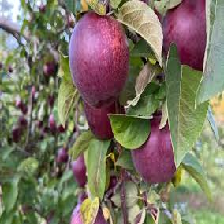

In [ ]:
img

In [ ]:
img_array

array([[[[234., 252., 255.],
         [229., 247., 255.],
         [183., 199., 215.],
         ...,
         [128., 151., 125.],
         [124., 146., 123.],
         [122., 144., 121.]],

        [[207., 225., 239.],
         [205., 222., 238.],
         [176., 191., 212.],
         ...,
         [123., 146., 120.],
         [121., 143., 120.],
         [119., 141., 118.]],

        [[207., 225., 239.],
         [205., 222., 238.],
         [176., 191., 212.],
         ...,
         [123., 146., 120.],
         [121., 143., 120.],
         [119., 141., 118.]],

        ...,

        [[ 61.,  95.,  35.],
         [ 81., 115.,  55.],
         [ 70., 105.,  51.],
         ...,
         [146., 195., 116.],
         [150., 199., 118.],
         [152., 201., 120.]],

        [[ 61.,  95.,  35.],
         [ 81., 115.,  55.],
         [ 70., 105.,  51.],
         ...,
         [146., 195., 116.],
         [150., 199., 118.],
         [152., 201., 120.]],

        [[ 77., 112.,  56.],
       

In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

img_array = preprocess_input(img_array)

In [ ]:
pred = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import decode_predictions

print(decode_predictions(pred, top=3))

[[('n07768694', 'pomegranate', np.float32(0.38202178)), ('n12620546', 'hip', np.float32(0.26879793)), ('n07753113', 'fig', np.float32(0.13987055))]]


# 📦 2.ResNet50

1️⃣ Load the pretrained model

In [ ]:
from tensorflow.keras.applications.resnet50 import ResNet50

model = ResNet50(weights="imagenet")

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [ ]:
from tensorflow.keras.preprocessing import image

img = image.load_img("/content/images.jpg", target_size=(224,224))

In [ ]:
import numpy as np

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

img_array = preprocess_input(img_array)

In [ ]:
pred = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [ ]:
from tensorflow.keras.applications.resnet50 import decode_predictions

print(decode_predictions(pred, top=3))

[[('n07768694', 'pomegranate', np.float32(0.4856234)), ('n12620546', 'hip', np.float32(0.24231562)), ('n07730033', 'cardoon', np.float32(0.065089))]]


| Part            | Meaning                        |
| --------------- | ------------------------------ |
| `n03376595`     | ImageNet class ID              |
| `folding_chair` | Predicted object label         |
| `0.5197621`     | Probability (confidence score) |


#  3. InceptionV3

This CNN uses multiple convolution filters of different sizes at the same time to capture more image features.

In [ ]:
from tensorflow.keras.applications.inception_v3 import InceptionV3

model = InceptionV3(weights="imagenet")

96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
from tensorflow.keras.preprocessing import image

img = image.load_img("/content/images.jpg", target_size=(299,299))

In [ ]:
import numpy as np

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

In [ ]:
from tensorflow.keras.applications.inception_v3 import preprocess_input

img_array = preprocess_input(img_array)

In [ ]:
pred = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


In [ ]:
from tensorflow.keras.applications.inception_v3 import decode_predictions

print(decode_predictions(pred, top=3))

[[('n07760859', 'custard_apple', np.float32(0.24887241)), ('n07768694', 'pomegranate', np.float32(0.23336463)), ('n07742313', 'Granny_Smith', np.float32(0.094382614))]]


#4. EfficientNet

In [ ]:
from tensorflow.keras.applications.efficientnet import EfficientNetB7

model = EfficientNetB7(weights="imagenet")

In [ ]:
from tensorflow.keras.preprocessing import image

img = image.load_img("/content/images.jpg", target_size = (600,600))

In [ ]:
import numpy as np

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input

img_array = preprocess_input(img_array)

In [ ]:
pred = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step


In [ ]:
from tensorflow.keras.applications.efficientnet import decode_predictions

print(decode_predictions(pred, top=3))

[[('n07768694', 'pomegranate', np.float32(0.68422425)), ('n07760859', 'custard_apple', np.float32(0.037350483)), ('n07753113', 'fig', np.float32(0.019079307))]]


# Object Detection

* We combine 2 files cats and dogs file as animals.
* Convert to Zip file.
* Load the zip file

In [ ]:
import zipfile
import os      #to check directory
import glob    #to see & handle folders
import numpy as np
from tensorflow.keras.preprocessing import image

# 1️⃣ Unzip the uploaded file
with zipfile.ZipFile("/content/ANIMAL.zip", "r") as zip_ref:
    zip_ref.extractall("/content")

# 2️⃣ Check folder structure
print("Folders inside /content/ANIMAL:", os.listdir("/content/ANIMAL"))

Folders inside /content/ANIMAL: ['ANIMAL', 'DOG', 'CAT']


In [ ]:
# Correct base path where dataset is extracted
base_dir = '/content/ANIMAL/ANIMAL'

# -----------------------------
# 1️⃣ Get image file paths
# -----------------------------

# glob searches for all files inside the folder
# 'cat' and 'dog' are folder names
# '*' means select all files in that folder

cat_paths = glob.glob(os.path.join(base_dir, 'CAT', '*'))   # All cat image paths
dog_paths = glob.glob(os.path.join(base_dir, 'DOG', '*'))   # All dog image paths

# Print number of images found
print('Found', len(cat_paths), 'cat images')
print('Found', len(dog_paths), 'dog images')


# -----------------------------
# 2️⃣ Create empty lists
# -----------------------------

# data → will store image pixel arrays
# labels → will store corresponding class labels

data = []
labels = []


# -----------------------------
# 3️⃣ Load and preprocess CAT images
# -----------------------------

for path in cat_paths:

    # Load image and resize to 150x150
    img = image.load_img(path, target_size=(150, 150))

    # Convert image to numpy array
    img_array = image.img_to_array(img)

    # Normalize pixel values from [0,255] → [0,1]
    img_array = img_array / 255.0

    # Store processed image
    data.append(img_array)

    # Assign label 0 for cat
    labels.append(0)


# -----------------------------
# 4️⃣ Load and preprocess DOG images
# -----------------------------

for path in dog_paths:

    # Load image and resize to 150x150
    img = image.load_img(path, target_size=(150, 150))

    # Convert image to numpy array
    img_array = image.img_to_array(img)

    # Normalize pixel values
    img_array = img_array / 255.0

    # Store processed image
    data.append(img_array)

    # Assign label 1 for dog
    labels.append(1)


# -----------------------------
# 5️⃣ Convert lists → NumPy arrays
# -----------------------------

# CNN models require numpy arrays
x = np.array(data)      # Image data
y = np.array(labels)    # Corresponding labels


# -----------------------------
# 6️⃣ Check dataset structure
# -----------------------------

print("✅ Data shape:", x.shape)   # (num_images, 150, 150, 3)
print("✅ Labels:", y)

Found 4 cat images
Found 4 dog images
✅ Data shape: (8, 150, 150, 3)
✅ Labels: [0 0 0 0 1 1 1 1]


In [ ]:
# Create an empty list to store labels
labels = []

# Loop through all cat image paths
for path in cat_paths:
    # Add label 'cat' for each cat image
    labels.append('cat')

# Loop through all dog image paths
for path in dog_paths:
    # Add label 'dog' for each dog image
    labels.append('dog')

# Example output
# This will print labels corresponding to the images
print(labels)  # ['cat', 'cat', 'dog', 'dog']

['cat', 'cat', 'cat', 'cat', 'dog', 'dog', 'dog', 'dog']


In [ ]:
x

array([[[[0.5882353 , 0.4509804 , 0.3254902 ],
         [0.5803922 , 0.44313726, 0.31764707],
         [0.5686275 , 0.43137255, 0.30588236],
         ...,
         [0.54509807, 0.36078432, 0.29803923],
         [0.5568628 , 0.37254903, 0.30980393],
         [0.57254905, 0.3882353 , 0.3254902 ]],

        [[0.58431375, 0.44705883, 0.32156864],
         [0.5764706 , 0.4392157 , 0.3137255 ],
         [0.5686275 , 0.43137255, 0.30588236],
         ...,
         [0.5529412 , 0.38431373, 0.30980393],
         [0.56078434, 0.39215687, 0.31764707],
         [0.57254905, 0.40392157, 0.32941177]],

        [[0.5647059 , 0.42745098, 0.30980393],
         [0.5647059 , 0.42745098, 0.30980393],
         [0.5647059 , 0.42745098, 0.30980393],
         ...,
         [0.54509807, 0.42352942, 0.3019608 ],
         [0.5529412 , 0.42352942, 0.29411766],
         [0.5568628 , 0.42745098, 0.29803923]],

        ...,

        [[0.3647059 , 0.31764707, 0.27058825],
         [0.36862746, 0.32156864, 0.27450982]

In [ ]:
y

array([0, 0, 0, 0, 1, 1, 1, 1])

In [ ]:
labels

['cat', 'cat', 'cat', 'cat', 'dog', 'dog', 'dog', 'dog']

In [ ]:
from tensorflow.keras import models, layers
from tensorflow.keras.utils import to_categorical

# Convert labels to one-hot
y_cat = to_categorical(y)
y_cat

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.]])

In [ ]:
# Build CNN
model = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(150, 150, 3)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(2, activation='softmax')
])

# Compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train
model.fit(x, y_cat, epochs=10, batch_size=32)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.5000 - loss: 0.6845
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 0.6883
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 0.7756
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 1.0000 - loss: 0.4290
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.3280
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.1708
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 0.0488
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 0.0129
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0027
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 8.6637e-04


Saving Funny_Dog_S.jpg to Funny_Dog_S.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
Predicted label for Funny_Dog_S.jpg: cat


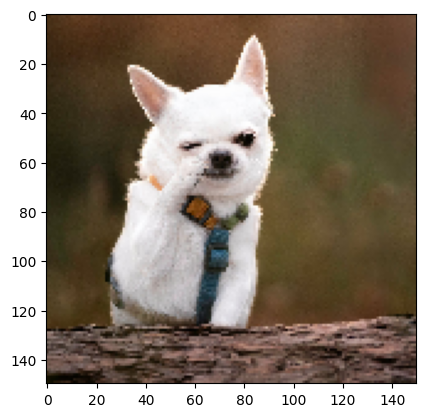

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# upload a new image
import matplotlib.pyplot as plt
from google.colab import files
uploaded = files.upload()

for img_name in uploaded.keys():
  img = image.load_img(img_name, target_size=(150, 150))
  plt.imshow(img)
  img_array = image.img_to_array(img) / 255.0
  img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

  pred = model.predict(img_array)
  class_idx = np.argmax(pred)
  label = "cat" if class_idx == 0 else "dog"
  print(f"Predicted label for {img_name}: {label}")


#Fruit detection

In [ ]:
import zipfile
import os
import glob
import numpy as np
from tensorflow.keras.preprocessing import image

# 1️⃣ Unzip the uploaded file
with zipfile.ZipFile("/content/fruits.zip", "r") as zip_ref:
    zip_ref.extractall("/content/fruits")

# 2️⃣ Check folder structure
print("Folders inside /content/fruits:", os.listdir("/content/fruits"))

Folders inside /content/fruits: ['fruits']


In [ ]:
# Correct base path where dataset is extracted
base_dir = '/content/fruits/fruits'

# -----------------------------
# 1️⃣ Get image file paths
# -----------------------------

# glob searches for all files inside the folder
# 'cat' and 'dog' are folder names
# '*' means select all files in that folder

green_apple_paths = glob.glob(os.path.join(base_dir, 'green apple', '*'))   # All green apple image paths
red_apple_paths = glob.glob(os.path.join(base_dir, 'red apple', '*'))   # All dred apple image paths

# Print number of images found
print('Found', len(green_apple_paths), 'green apple images')
print('Found', len(red_apple_paths), 'red apple images')


# -----------------------------
# 2️⃣ Create empty lists
# -----------------------------

# data → will store image pixel arrays
# labels → will store corresponding class labels

data = []
labels = []


# -----------------------------
# 3️⃣ Load and preprocess CAT images
# -----------------------------

for path in green_apple_paths:

    # Load image and resize to 150x150
    img = image.load_img(path, target_size=(150, 150))

    # Convert image to numpy array
    img_array = image.img_to_array(img)

    # Normalize pixel values from [0,255] → [0,1]
    img_array = img_array / 255.0

    # Store processed image
    data.append(img_array)

    # Assign label 0 for cat
    labels.append(0)


# -----------------------------
# 4️⃣ Load and preprocess DOG images
# -----------------------------

for path in red_apple_paths:

    # Load image and resize to 150x150
    img = image.load_img(path, target_size=(150, 150))

    # Convert image to numpy array
    img_array = image.img_to_array(img)

    # Normalize pixel values
    img_array = img_array / 255.0

    # Store processed image
    data.append(img_array)

    # Assign label 1 for dog
    labels.append(1)


# -----------------------------
# 5️⃣ Convert lists → NumPy arrays
# -----------------------------

# CNN models require numpy arrays
x = np.array(data)      # Image data
y = np.array(labels)    # Corresponding labels


# -----------------------------
# 6️⃣ Check dataset structure
# -----------------------------

print("✅ Data shape:", x.shape)   # (num_images, 150, 150, 3)
print("✅ Labels:", y)

Found 4 green apple images
Found 4 red apple images
✅ Data shape: (8, 150, 150, 3)
✅ Labels: [0 0 0 0 1 1 1 1]


In [ ]:
# Create an empty list to store labels
labels = []

# Loop through all green apple image paths
for path in green_apple_paths:
    # Add label 'green_apple' for each cat image
    labels.append('green_apple')

# Loop through all red_apple image paths
for path in red_apple_paths:
    # Add label 'red apple' for each dog image
    labels.append('red_apple')

# Example output
# This will print labels corresponding to the images
print(labels)  # ['green_apple', 'green_apple', 'red_apple', 'red_apple']

['green_apple', 'green_apple', 'green_apple', 'green_apple', 'red_apple', 'red_apple', 'red_apple', 'red_apple']


In [ ]:
x

array([[[[0.6       , 0.56078434, 0.52156866],
         [0.60784316, 0.5686275 , 0.5294118 ],
         [0.6117647 , 0.57254905, 0.53333336],
         ...,
         [0.47843137, 0.44313726, 0.40784314],
         [0.47843137, 0.44313726, 0.40784314],
         [0.4745098 , 0.4392157 , 0.40392157]],

        [[0.59607846, 0.5568628 , 0.5176471 ],
         [0.6039216 , 0.5647059 , 0.5254902 ],
         [0.60784316, 0.5686275 , 0.5294118 ],
         ...,
         [0.48235294, 0.44705883, 0.4117647 ],
         [0.48235294, 0.44705883, 0.4117647 ],
         [0.47843137, 0.44313726, 0.40784314]],

        [[0.5921569 , 0.5529412 , 0.5137255 ],
         [0.6       , 0.56078434, 0.52156866],
         [0.6039216 , 0.5647059 , 0.5254902 ],
         ...,
         [0.4862745 , 0.4509804 , 0.41568628],
         [0.4862745 , 0.4509804 , 0.41568628],
         [0.48235294, 0.44705883, 0.4117647 ]],

        ...,

        [[0.6745098 , 0.70980394, 0.7294118 ],
         [0.6745098 , 0.70980394, 0.7294118 ]

In [ ]:
y

array([0, 0, 0, 0, 1, 1, 1, 1])

In [ ]:
labels

['green_apple',
 'green_apple',
 'green_apple',
 'green_apple',
 'red_apple',
 'red_apple',
 'red_apple',
 'red_apple']

In [ ]:
from tensorflow.keras import models, layers
from tensorflow.keras.utils import to_categorical

# Convert labels to one-hot
y_cat = to_categorical(y)
y_cat

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.]])

In [ ]:
# Build CNN
model = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(150, 150, 3)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(2, activation='softmax')
])

# Compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train
model.fit(x, y_cat, epochs=10, batch_size=32)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.5000 - loss: 0.6913
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.4947
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0502
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5000 - loss: 4.4917
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 0.1111
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 1.7880
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 0.0356
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0027
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 0.0134
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 0.0192


Saving images.jpg to images (5).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Predicted label for images (5).jpg: green apple


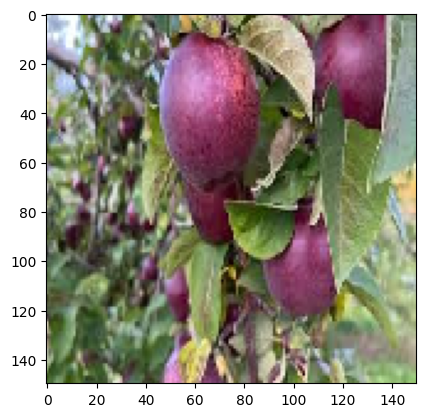

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# upload a new image
import matplotlib.pyplot as plt
from google.colab import files
uploaded = files.upload()

for img_name in uploaded.keys():
  img = image.load_img(img_name, target_size=(150, 150))
  plt.imshow(img)
  img_array = image.img_to_array(img) / 255.0
  img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

  pred = model.predict(img_array)
  class_idx = np.argmax(pred)
  label = "green apple" if class_idx == 0 else "red apple"
  print(f"Predicted label for {img_name}: {label}")
